# Ejercicio 6 - Parquet versus tablas DuckDB

`scripts/run_benchmark.py` materializa 2024 y 2026 en
`data/processed/taxi_benchmark.duckdb` (6.2), ejecuta las mismas tres consultas sobre
Parquet y sobre la tabla (6.4), con 2024, 2026 y ambos anios (6.6), repitiendo cada
medicion y guardando la primera ejecucion y la mediana (6.5).

El benchmark tarda varios minutos. Cambie `EJECUTAR` a `True` para repetirlo; si no,
se usan los resultados guardados en `docs/ejercicio_6_benchmark.csv`.

In [1]:
import lab_utils
EJECUTAR = False
if EJECUTAR:
    !python scripts/run_benchmark.py

## 6.3 y 6.8. Consultas del benchmark

In [2]:
from lab_utils import consultas
from IPython.display import Markdown, display

for c in consultas("04_benchmark.sql").values():
    display(Markdown(f"**{c.metadatos['title']}** - {c.metadatos['objective']}\n\n```sql\n{c.sql}\n```"))

**Resumen mensual** - Medir una agregacion temporal con conteo, promedio y suma.

```sql
SELECT anio, month(pickup_datetime) AS mes, tipo_taxi, count(*) AS viajes,
       avg(trip_distance) AS distancia_media, sum(total_amount) AS monto_total
FROM {source}
WHERE {year_filter}
GROUP BY anio, mes, tipo_taxi
ORDER BY anio, mes, tipo_taxi;
```

**Distribucion de pagos** - Medir una agrupacion de baja cardinalidad sobre varias columnas.

```sql
SELECT anio, tipo_taxi, payment_type, count(*) AS viajes,
       avg(fare_amount) AS tarifa_media, avg(tip_amount) AS propina_media
FROM {source}
WHERE {year_filter}
GROUP BY anio, tipo_taxi, payment_type
ORDER BY anio, tipo_taxi, viajes DESC;
```

**Rutas principales** - Medir una agrupacion de mayor cardinalidad y un ranking por ventana.

```sql
WITH rutas AS (
    SELECT anio, tipo_taxi, pickup_location_id, dropoff_location_id, count(*) AS viajes
    FROM {source}
    WHERE {year_filter}
    GROUP BY ALL
)
SELECT * FROM rutas
QUALIFY row_number() OVER (PARTITION BY anio, tipo_taxi ORDER BY viajes DESC) <= 20
ORDER BY anio, tipo_taxi, viajes DESC;
```

`{source}` se reemplaza por una lectura normalizada de los Parquet (`read_parquet`
con `union_by_name`) o por la tabla `viajes`; `{year_filter}` por el escenario.

## 6.7. Resultados

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

bench = pd.read_csv("docs/ejercicio_6_benchmark.csv")
tabla = bench.pivot_table(index=["escenario", "registros", "consulta"], columns="fuente", values="mediana_s")
tabla["parquet/duckdb"] = tabla["parquet"] / tabla["duckdb"]
tabla

fuente                                    duckdb  parquet  parquet/duckdb
escenario registros consulta                                             
2024      41829938  01_resumen_mensual      1.03     2.76            2.69
                    02_distribucion_pago    0.69     0.87            1.26
                    03_rutas_principales    0.75     0.93            1.24
2024+2026 71870407  01_resumen_mensual      1.84     2.84            1.54
                    02_distribucion_pago    1.33     1.37            1.03
                    03_rutas_principales    1.64     2.00            1.22
2026      30040469  01_resumen_mensual      0.62     1.28            2.06
                    02_distribucion_pago    0.54     0.63            1.17
                    03_rutas_principales    0.62     0.76            1.22

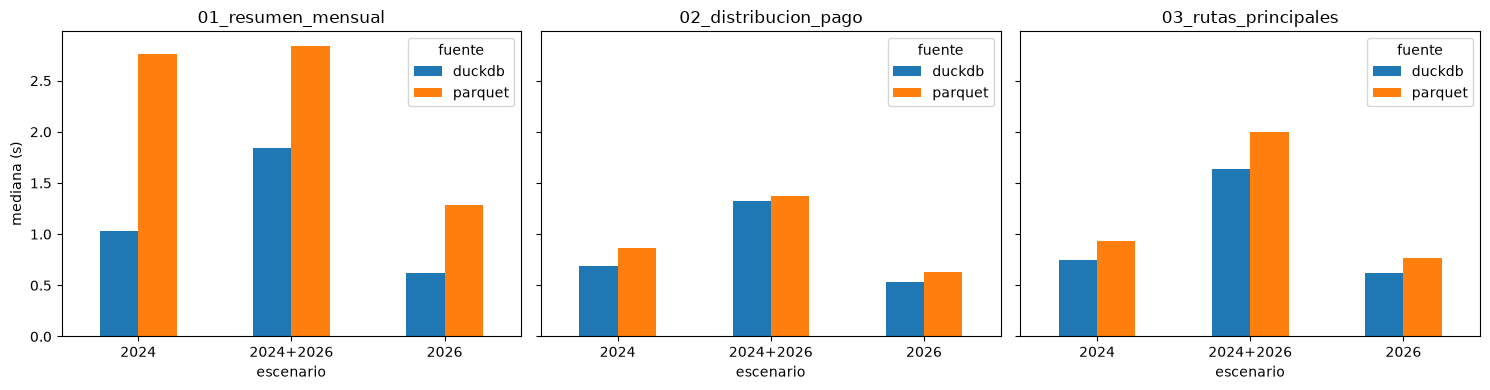

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, (consulta, d) in enumerate(bench.groupby("consulta")):
    d.pivot(index="escenario", columns="fuente", values="mediana_s").plot.bar(ax=ax[i], rot=0, title=consulta)
ax[0].set_ylabel("mediana (s)")
plt.tight_layout()

## 6.9. Analisis

La tabla DuckDB suele ser mas rapida porque evita interpretar multiples archivos y sus
metadatos en cada consulta, y sus datos ya estan normalizados. A cambio exige tiempo y
espacio para materializarse, tiempo que se reporta por separado. La primera ejecucion
incluye calentamiento de paginas y metadatos, por eso no se mezcla con la mediana.

La ventaja depende de la consulta: es mayor en el resumen mensual (entre 1.5 y 2.7
veces) y pequena en la distribucion de pagos (entre 1.03 y 1.26 veces). Ademas, no crece con el volumen: con 2024+2026 la razon
Parquet/DuckDB es menor que con un solo anio, por lo que duplicar los datos no hace
que la materializacion sea proporcionalmente mas ventajosa.

## 6.10. Cuando usar cada estrategia

- **Parquet directo**: datos que llegan como archivos, exploraciones ocasionales,
  consultas sobre pocas columnas y cuando se quiere evitar duplicar almacenamiento.
- **Tabla materializada**: consultas y transformaciones que se repiten, necesidad de
  un esquema limpio y estable, o varios usuarios/herramientas (como Metabase)
  consultando el mismo resultado, de modo que el costo de carga se amortiza.